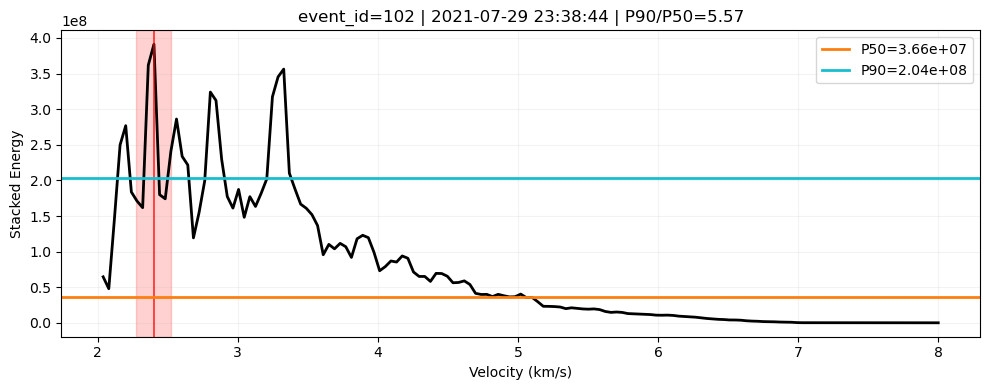

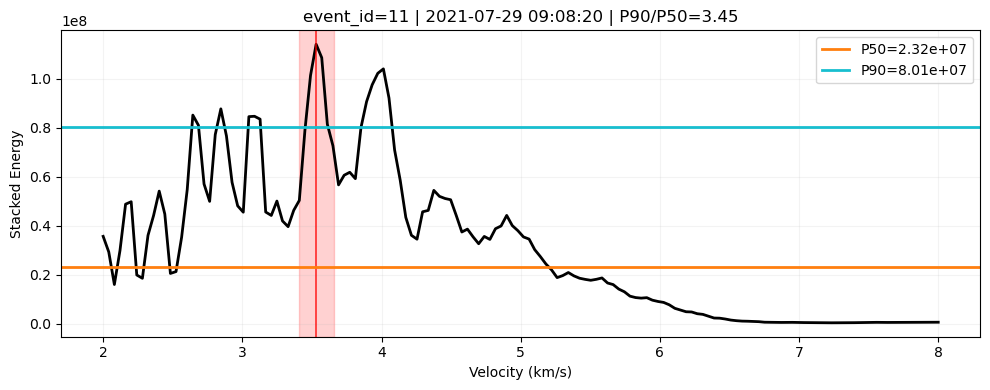

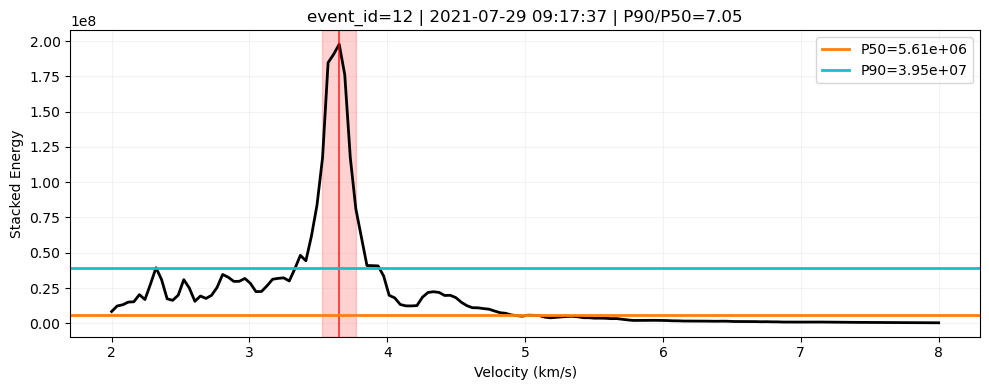

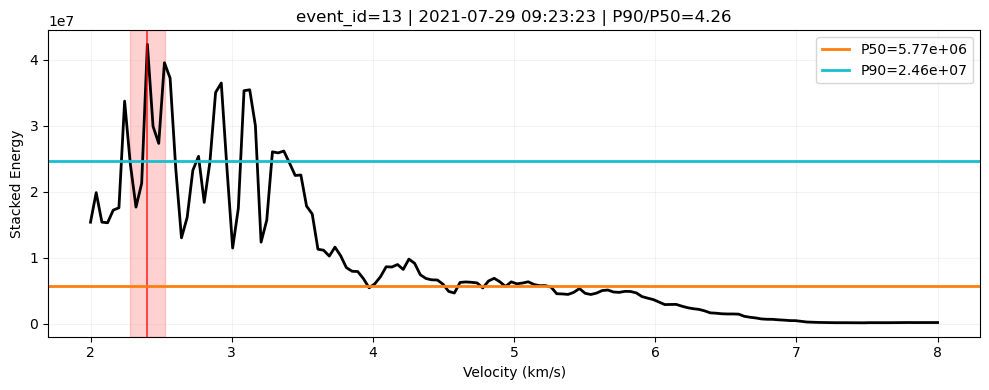

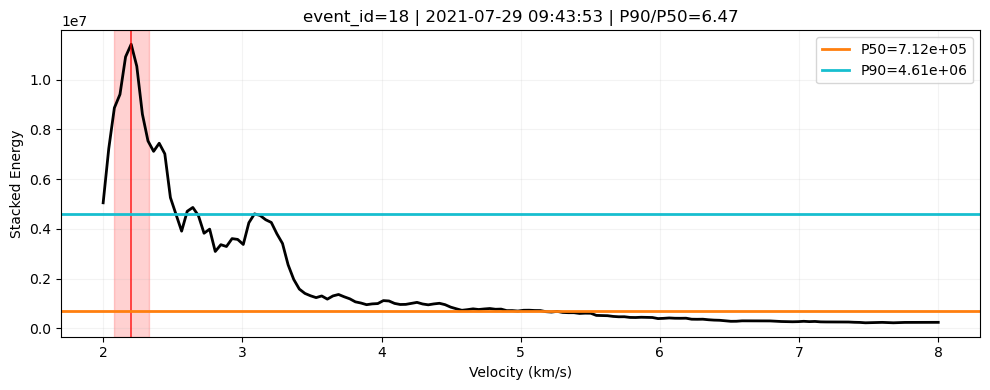

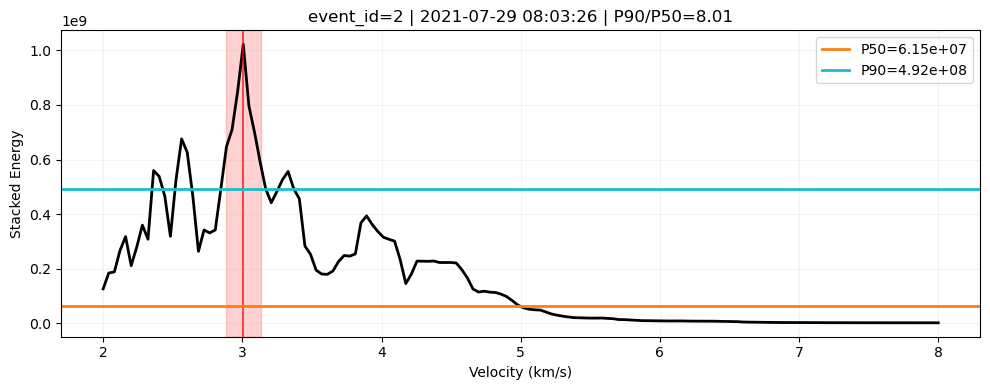

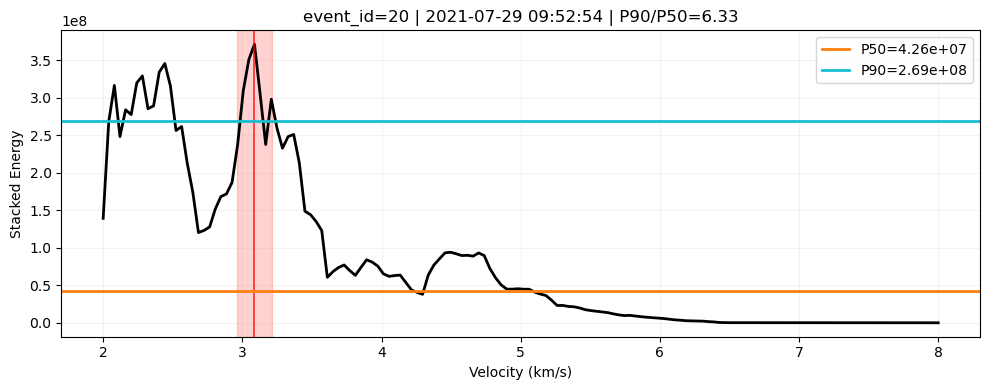

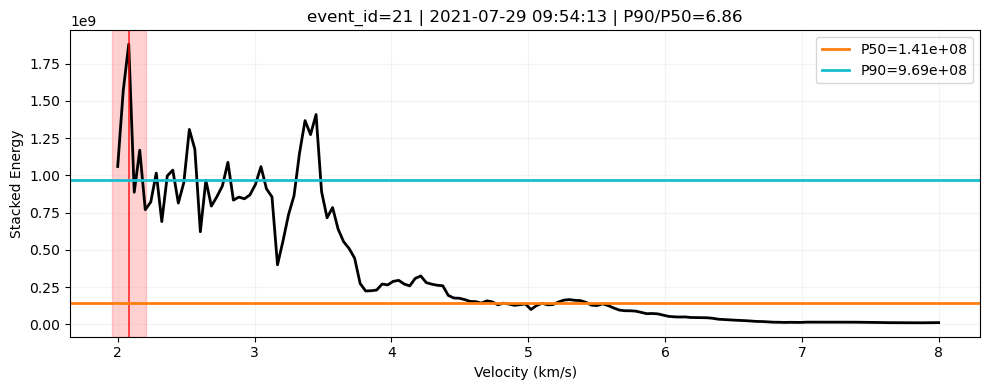

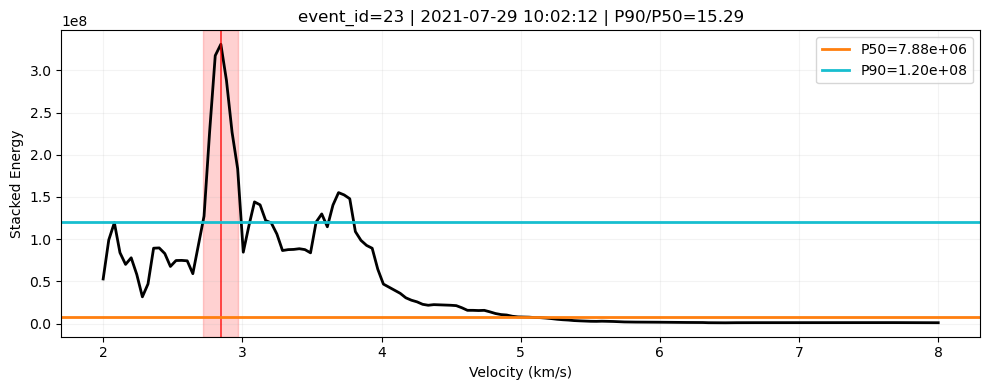

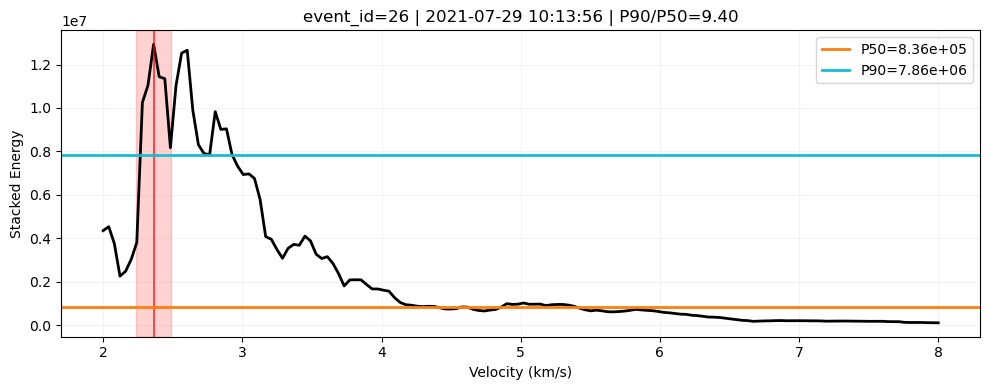

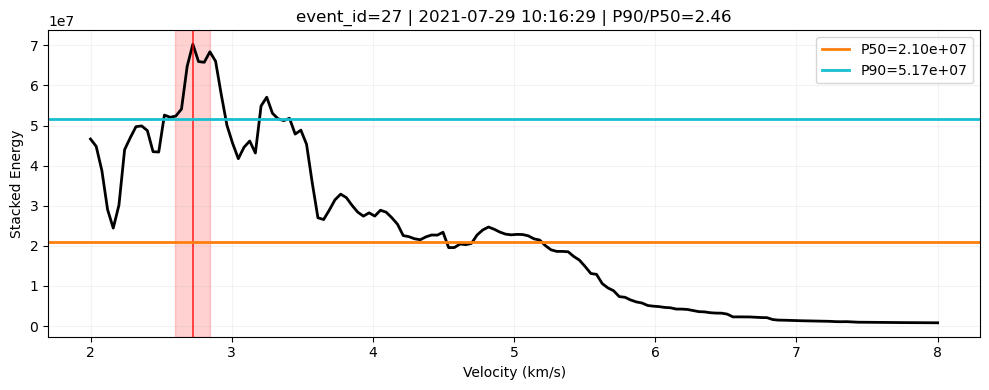

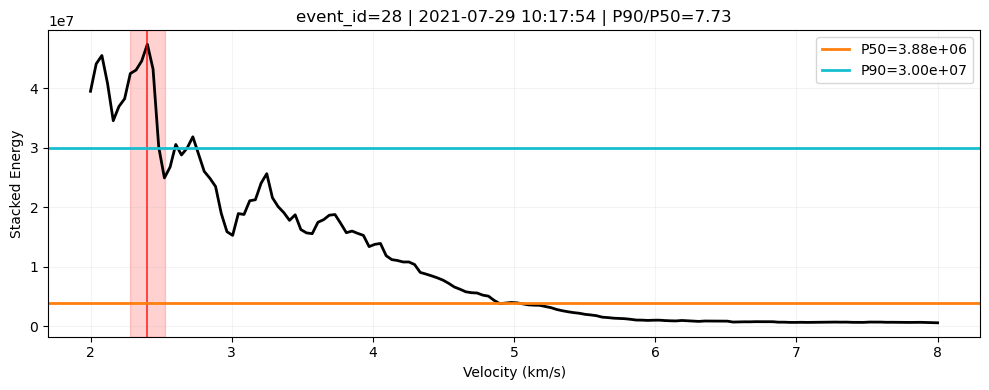

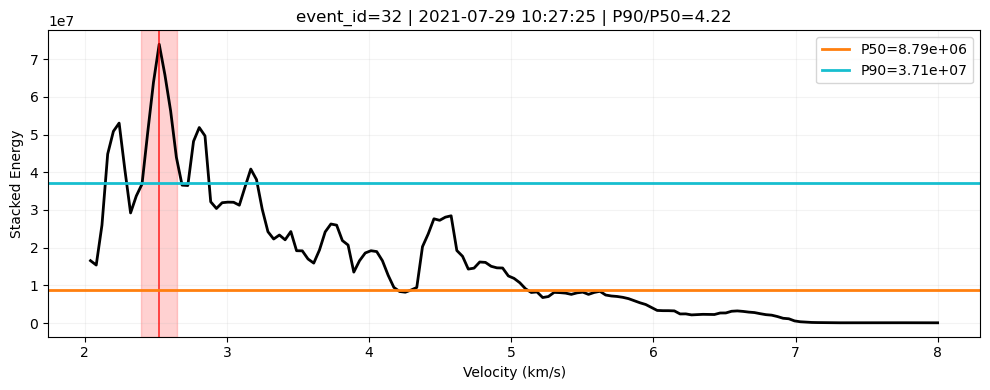

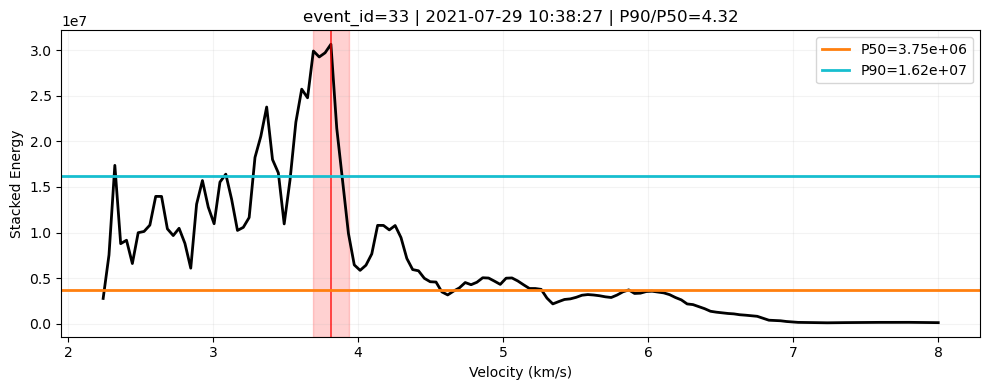

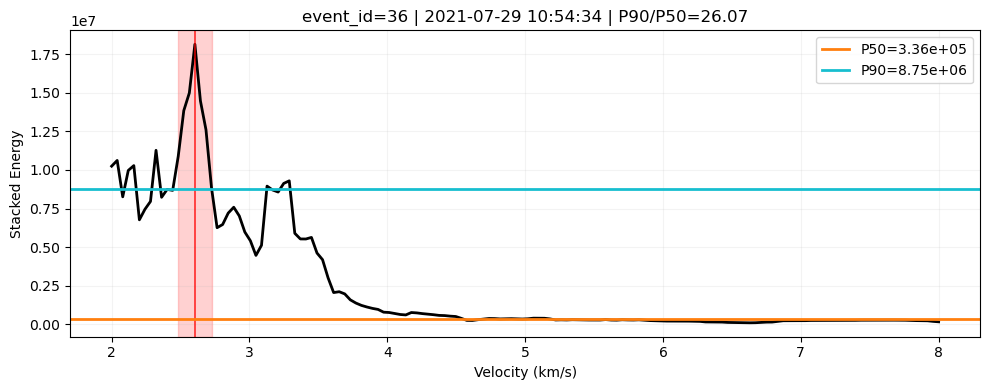

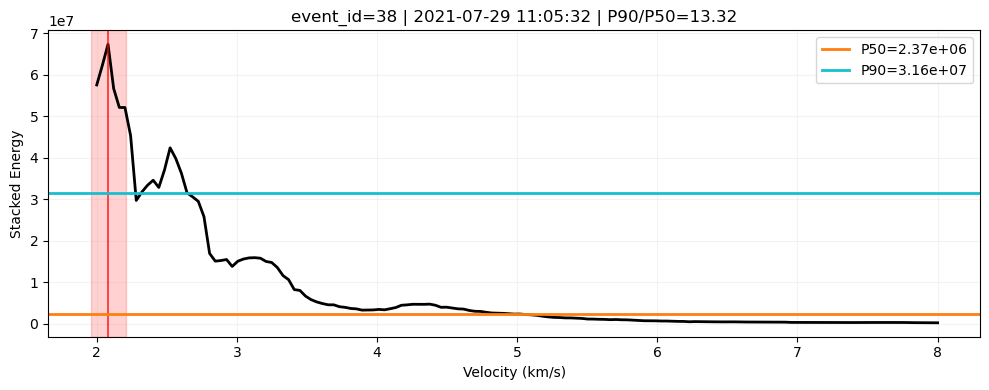

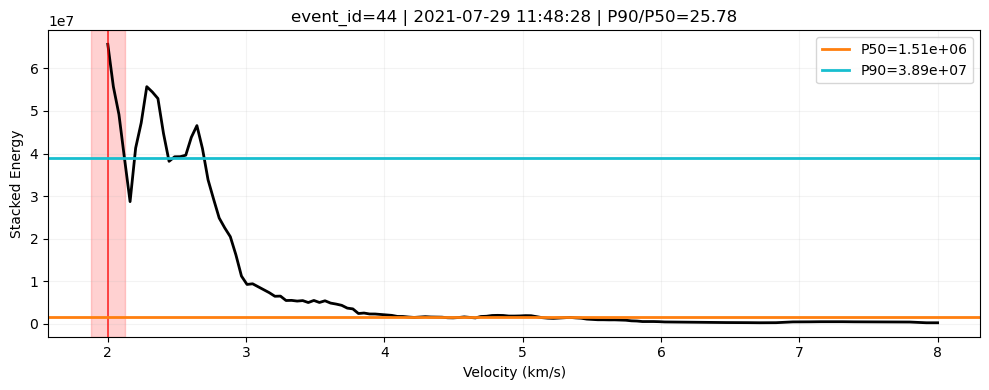

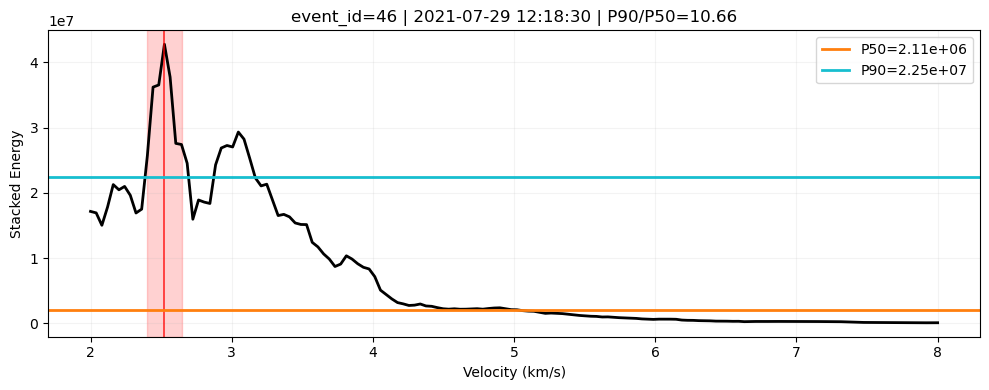

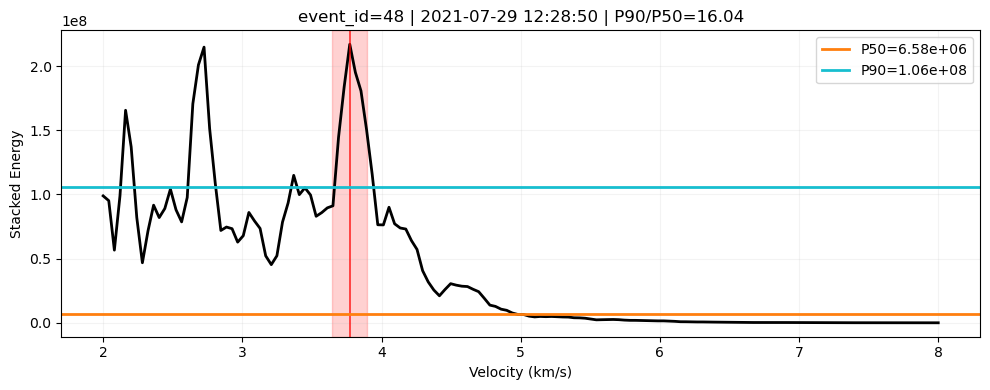

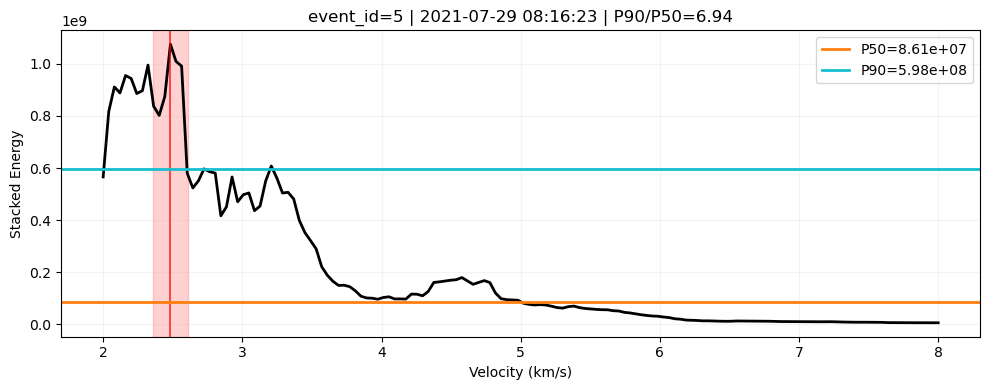

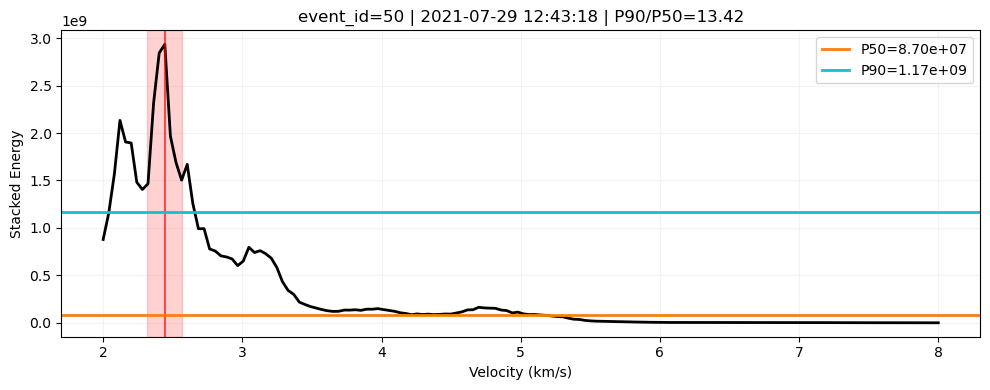

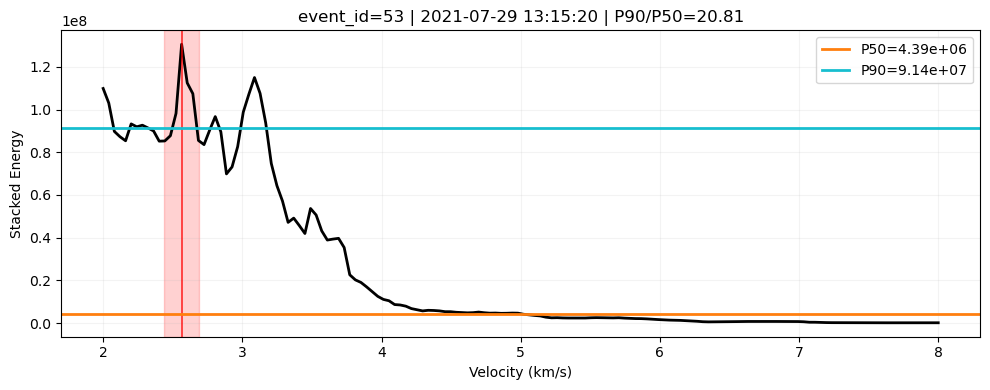

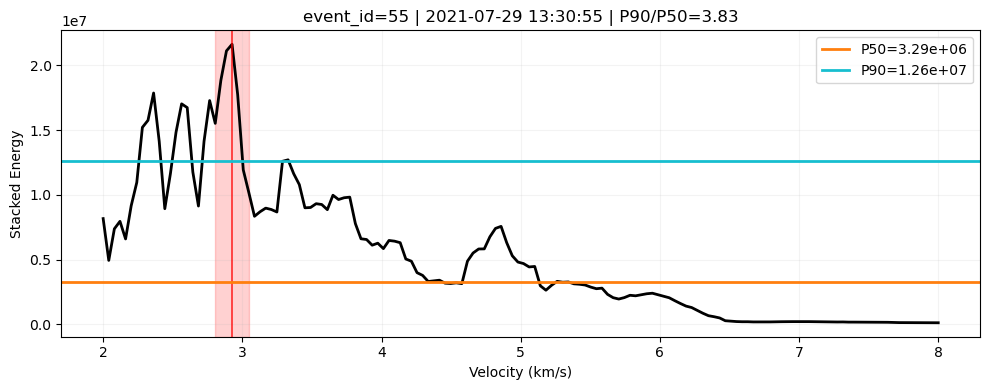

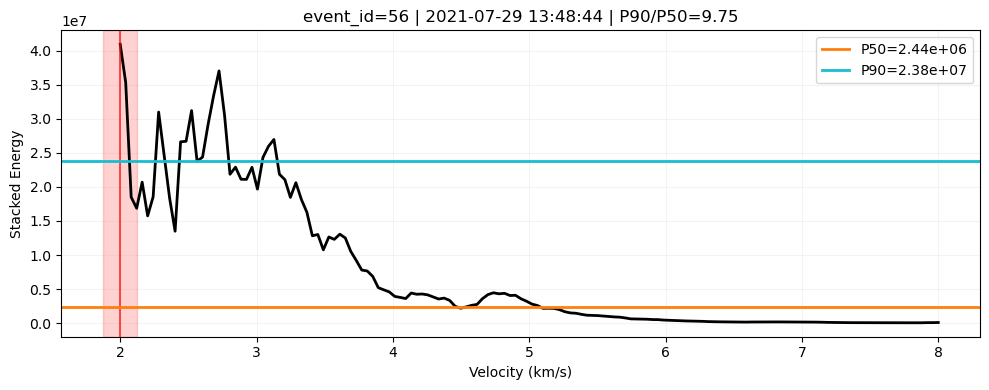

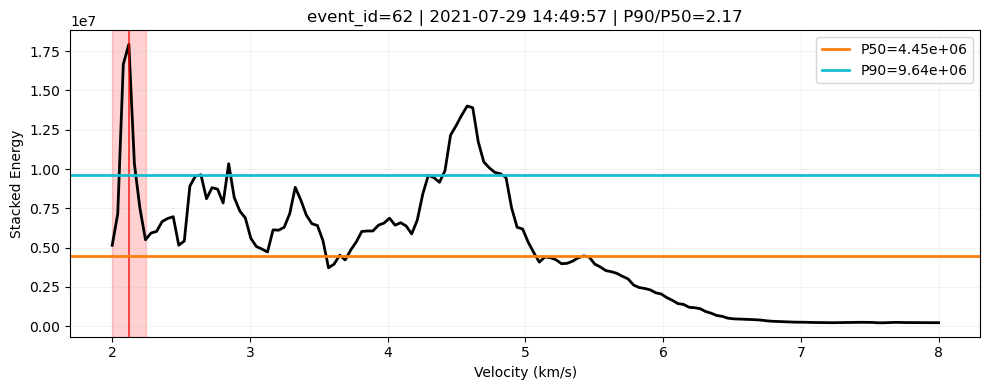

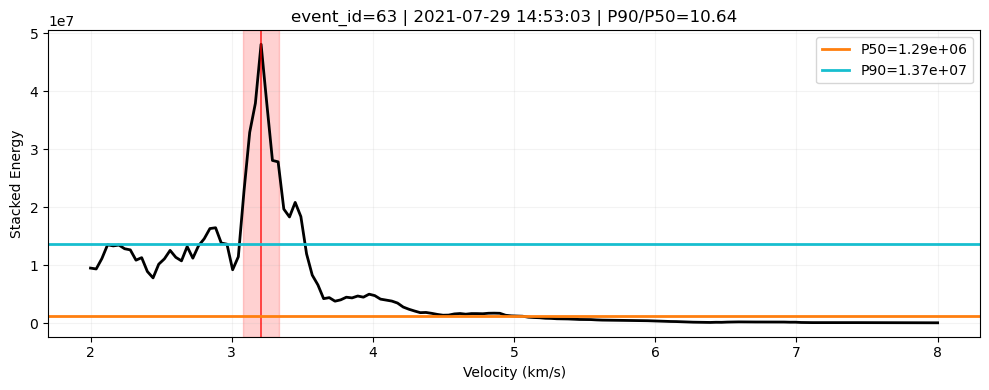

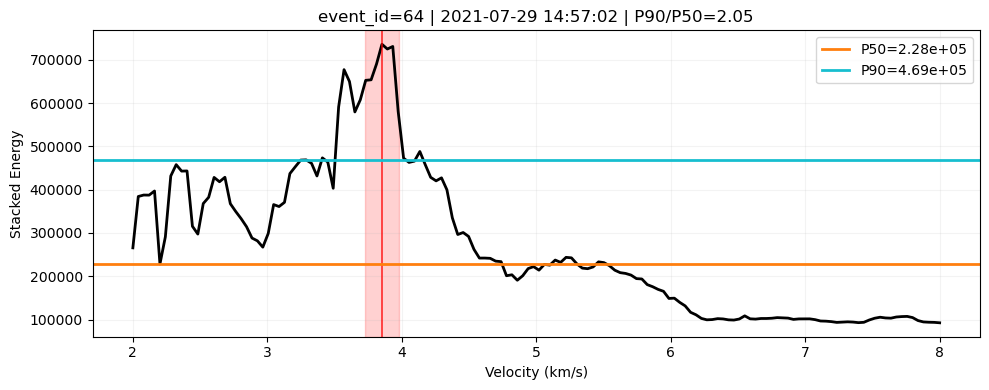

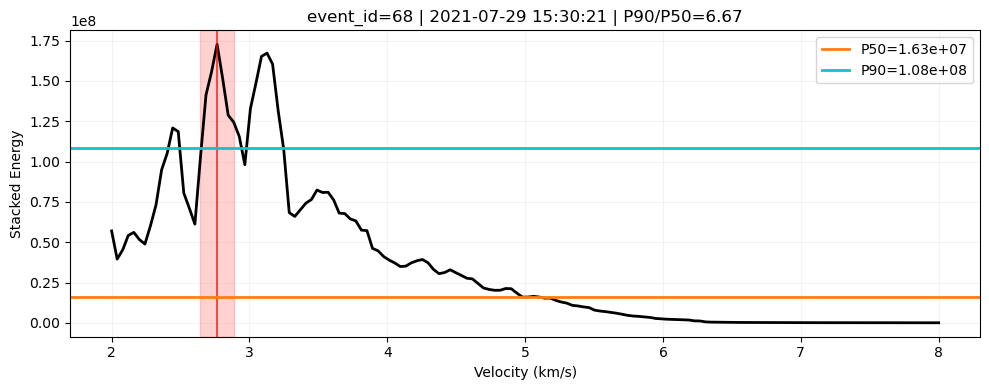

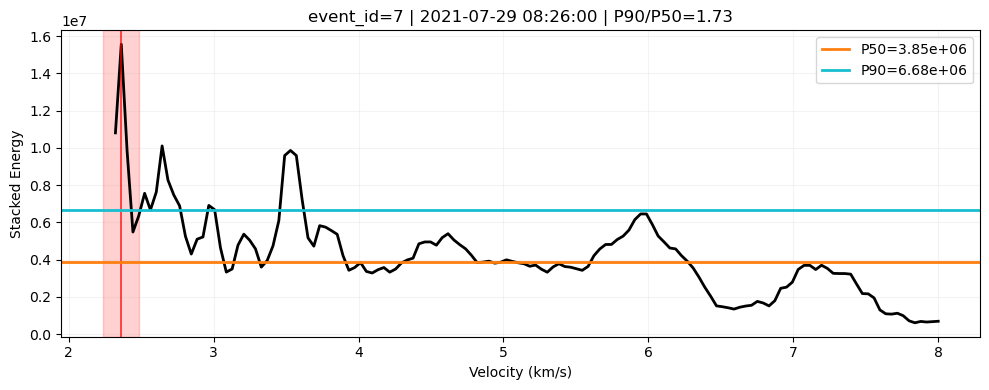

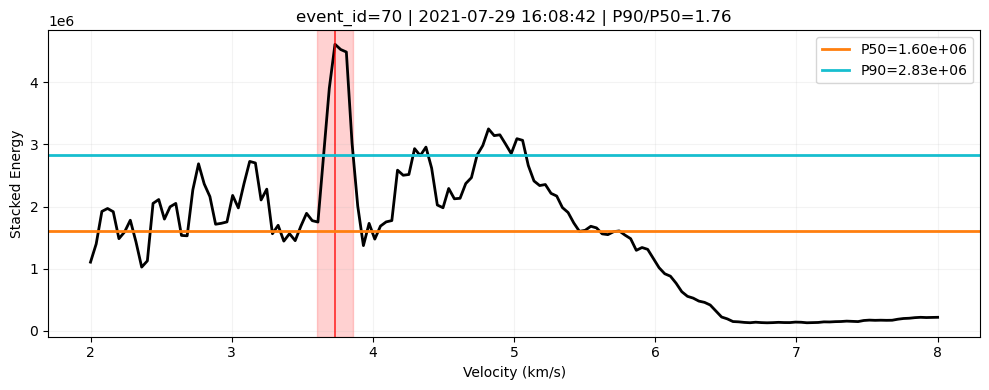

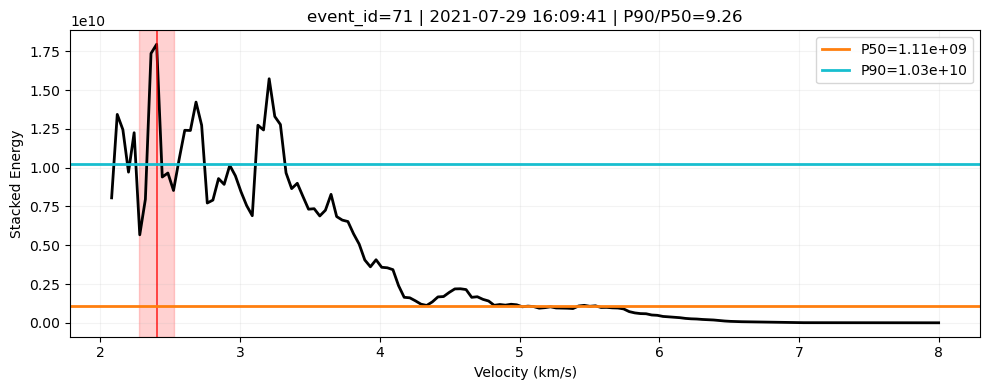

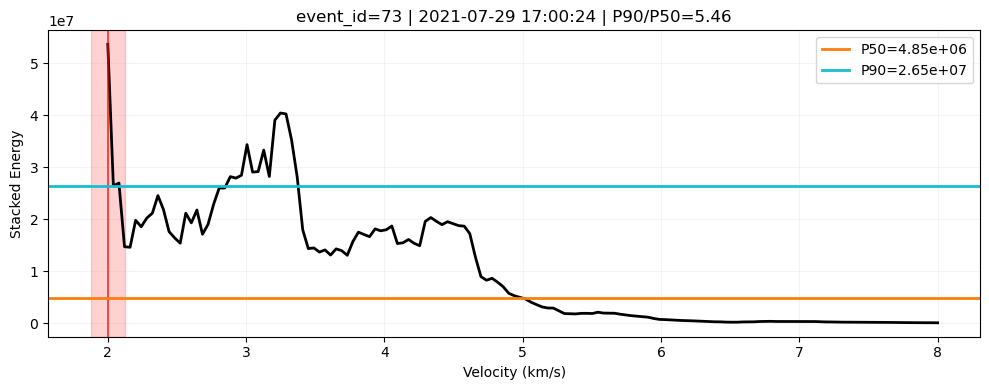

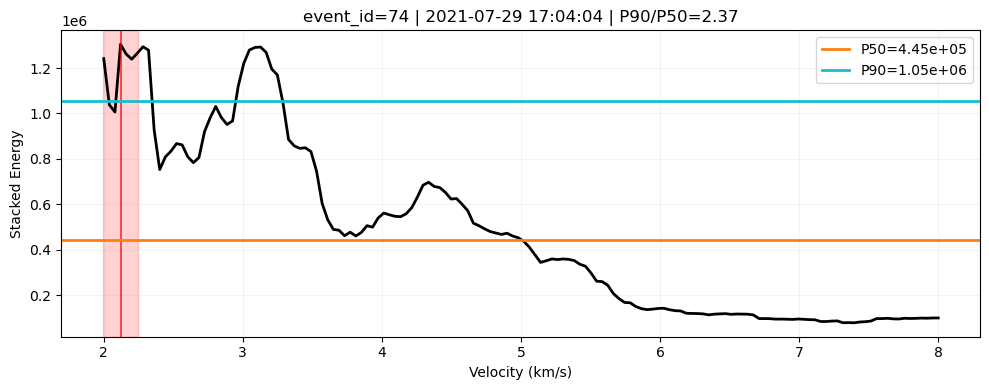

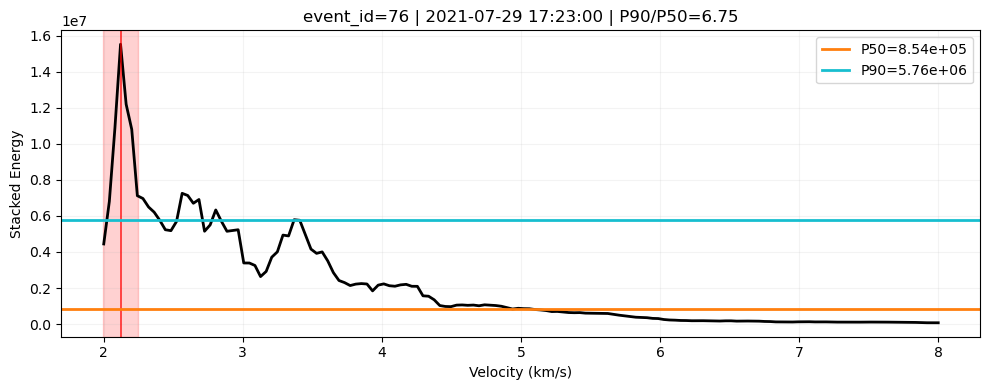

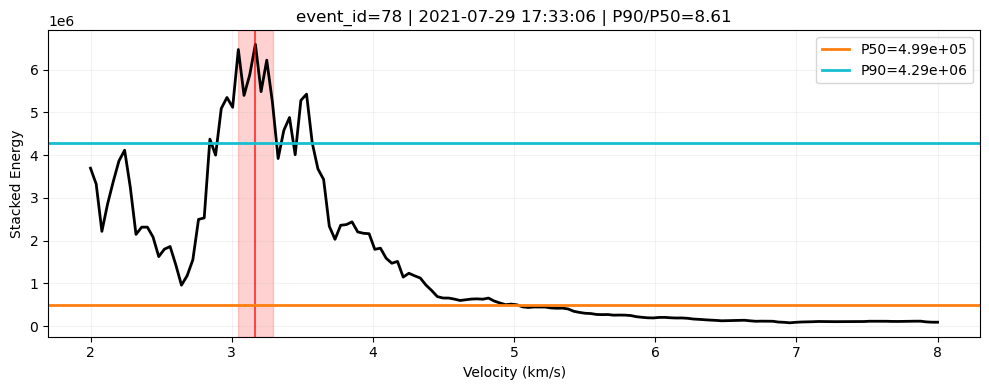

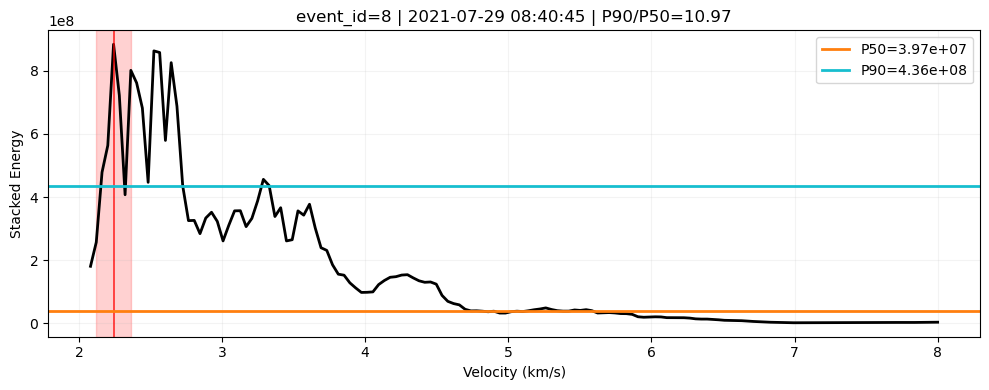

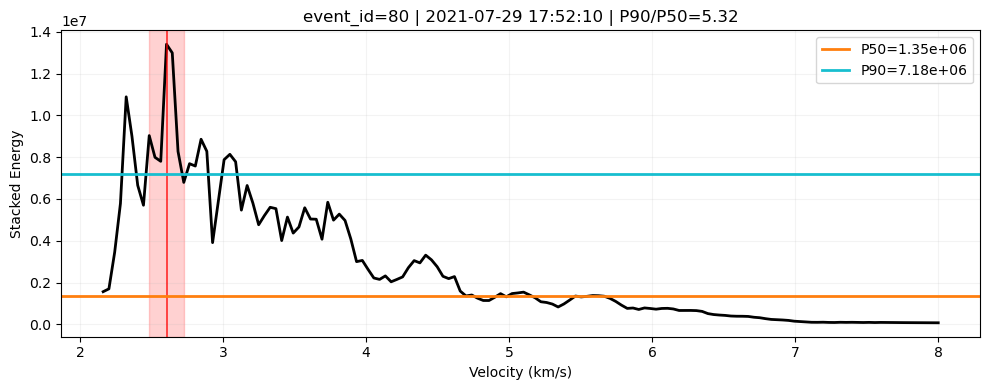

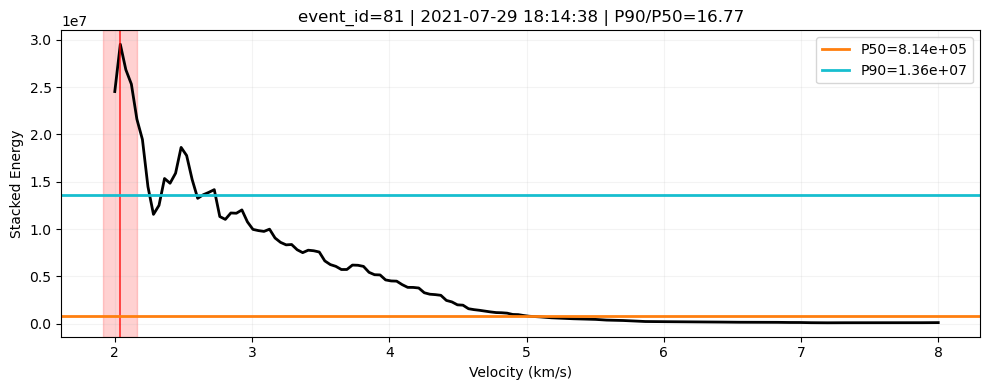

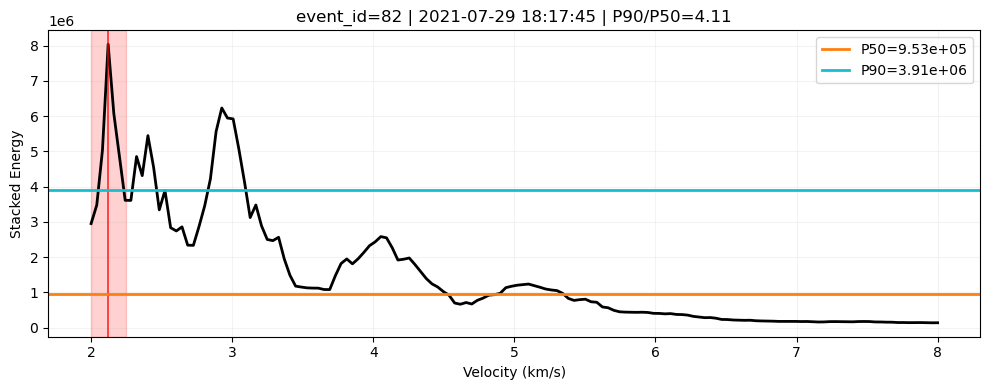

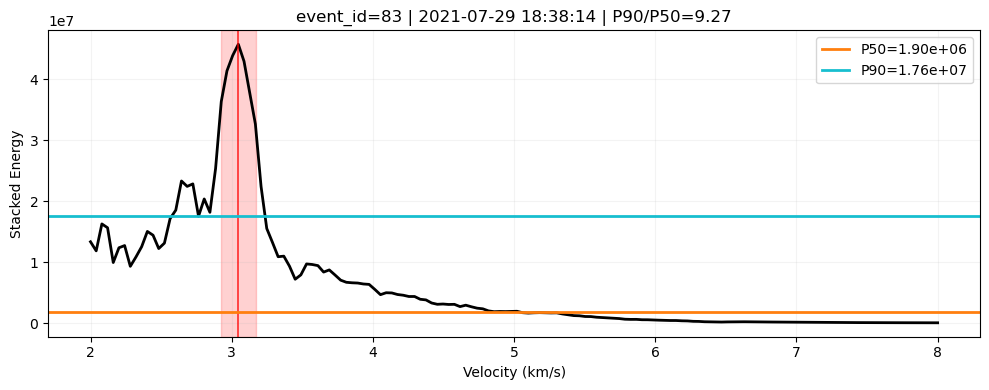

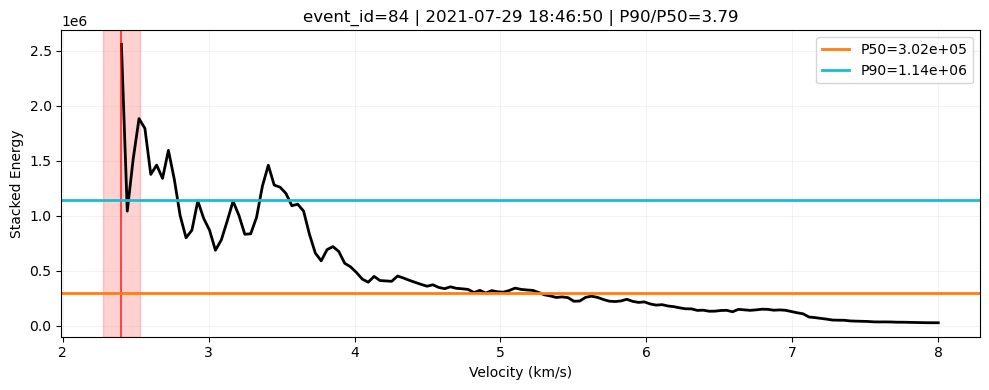

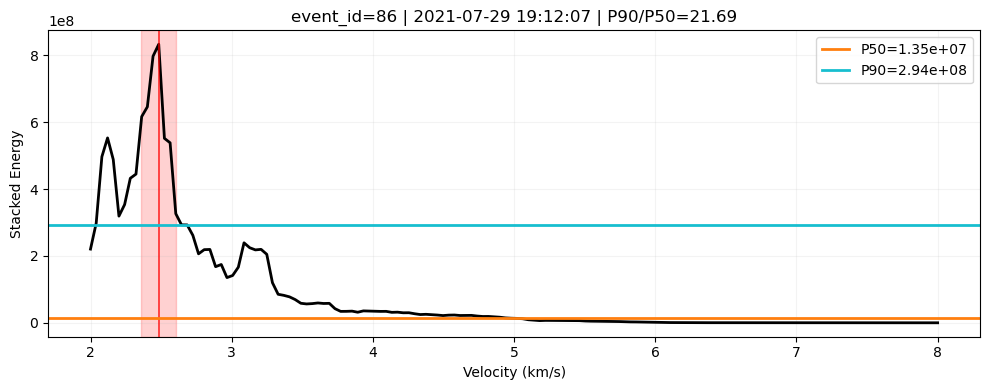

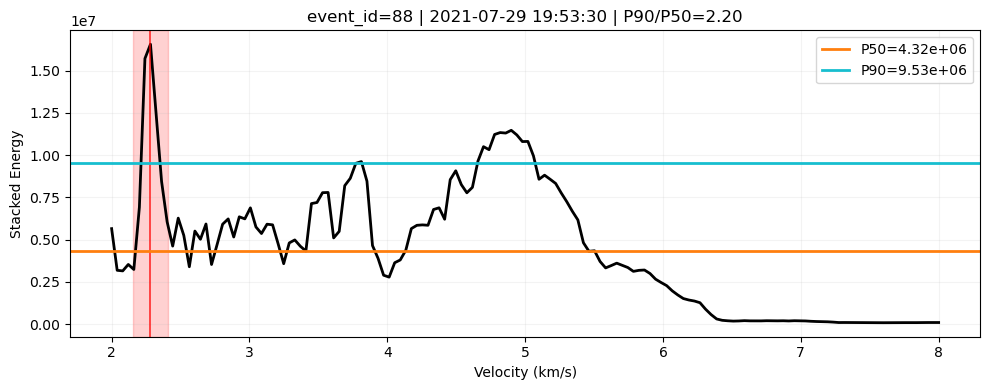

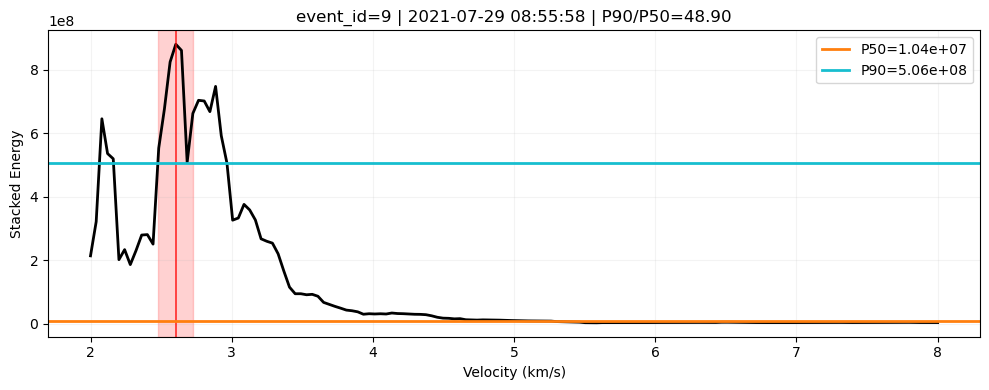

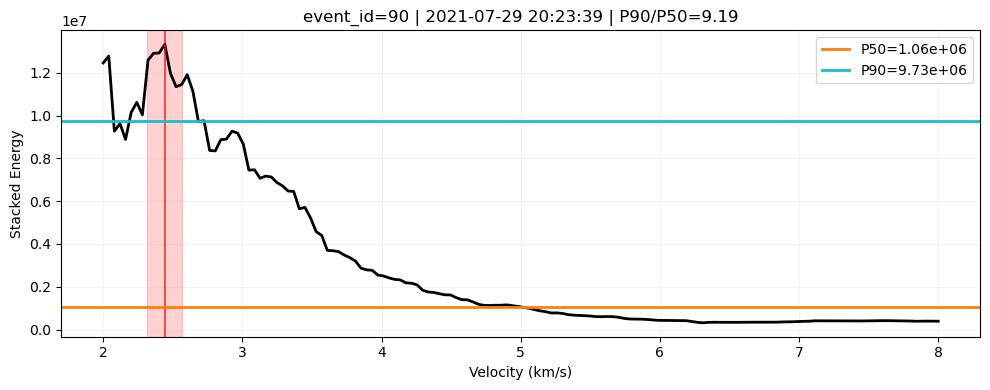

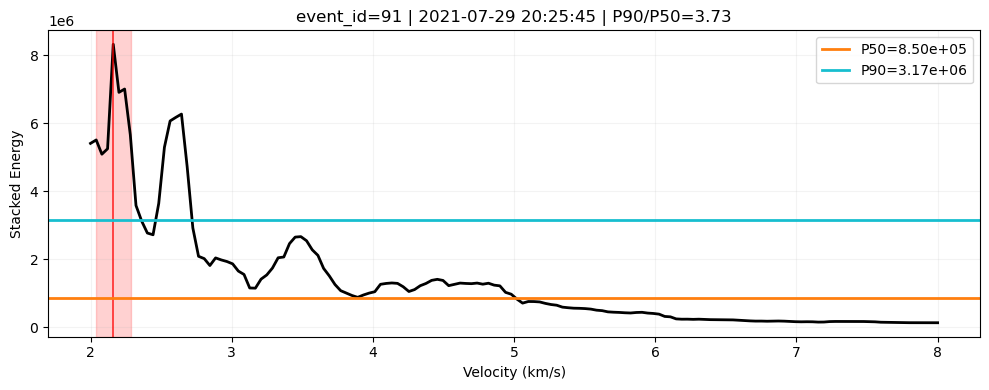

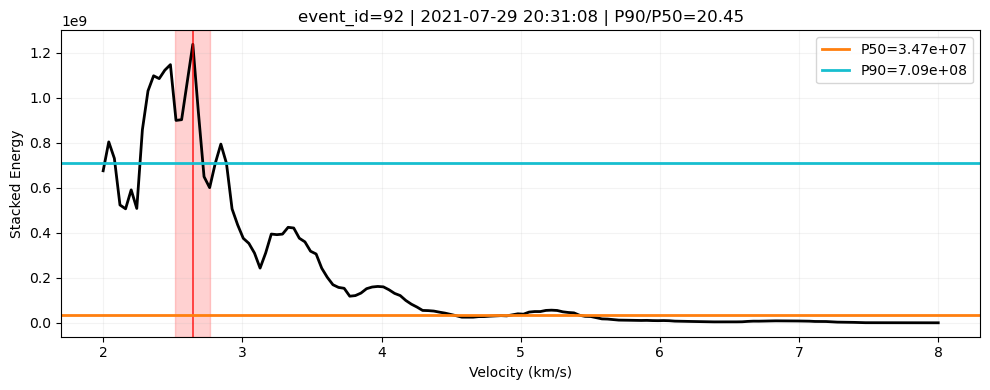

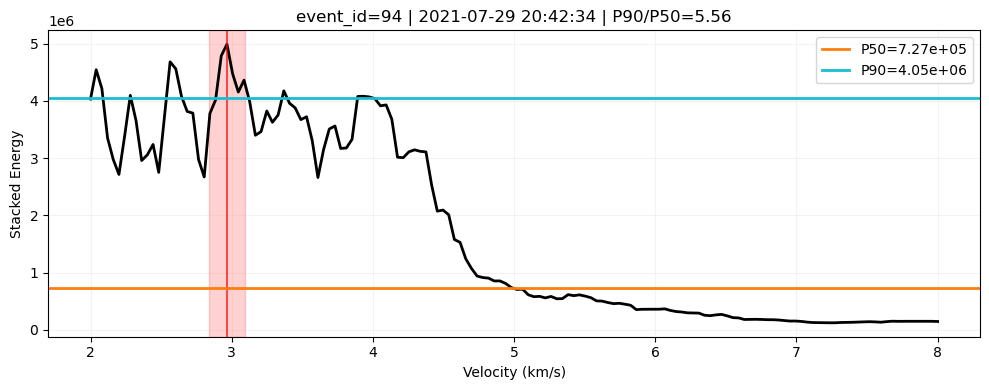

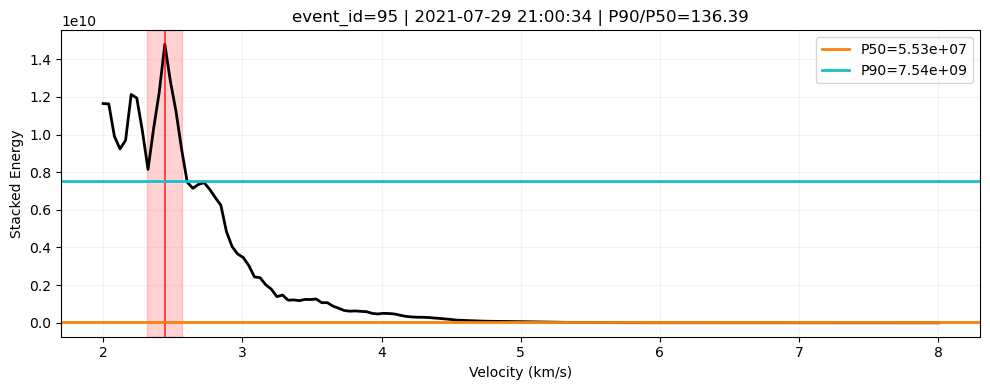

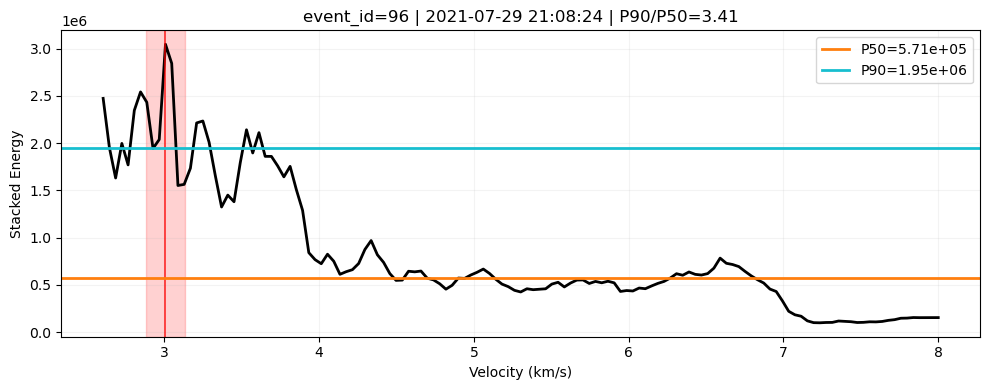

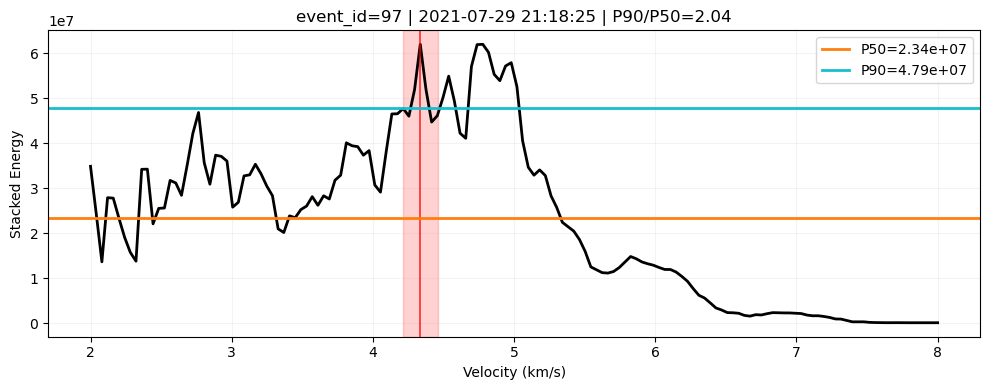

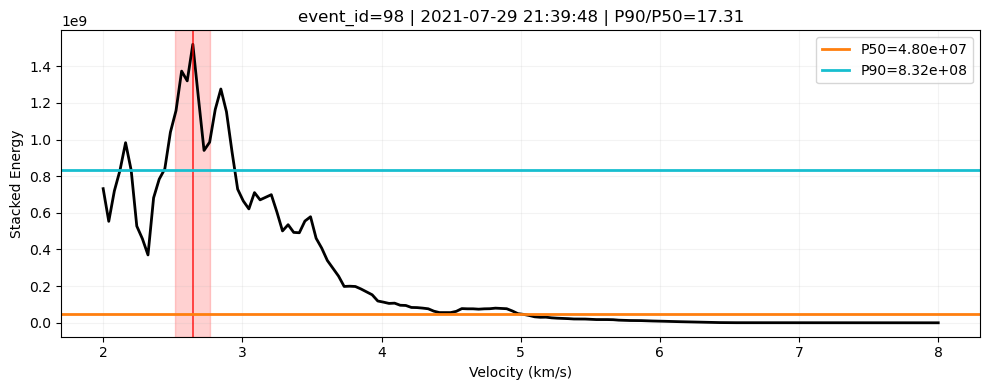


Wrote: /home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_qc.csv
 event_id                             time  best_v_km_s  peak_energy  peak_percentile_rank  noise_percentile  noise_energy  signal_percentile  signal_ref_energy  snr_percentile_ratio  freqmin  freqmax  num_stations  min_valid_stations_per_v  n_files
      102 2021-07-29 23:38:44.800000+00:00     2.402685 3.910181e+08                 100.0              50.0  3.659264e+07               90.0       2.037904e+08              5.569164      1.0     15.0            11                         4        2
       11 2021-07-29 09:08:20.310000+00:00     3.530201 1.140351e+08                 100.0              50.0  2.320375e+07               90.0       8.013670e+07              3.453610      1.0     15.0            10                         4        2
       12 2021-07-29 09:17:37.990000+00:00     3.651007 1.977606e+08                 100.0              50.0  5.609162e+06               90.0       3.953075e+07              

In [18]:
from pathlib import Path
from typing import Dict, Tuple, Optional, List
import re
from datetime import datetime
from bisect import bisect_right

import numpy as np
import pandas as pd
import obspy
from obspy import read, UTCDateTime
from obspy.geodetics.base import gps2dist_azimuth

# USER SETTINGS

DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data")
NAMEBASE  = "GAMMA"

PRE_S   = 10.0
POST_S  = 40.0

# Single  bandpass
FREQMIN = 1.0
FREQMAX = 15.0

# Signal range used to report peak position
VMIN_SIGNAL = 2.0
VMAX_SIGNAL = 8.0

# Velocity grid 
VMIN_CURVE   = 2.0
VMAX_CURVE   = 8.0
VSTEPS_CURVE = 150

WINLEN  = 1

PAD_NEIGHBORS   = True
GEOM_CORRECTION = False
EPS             = 1e-12

MAKE_PLOT  = True
MAX_EVENTS = 0   # 0 = all

# Two percentiles for QC
NOISE_PERCENTILE  = 50.0
SIGNAL_PERCENTILE = 90.0

MIN_TOTAL_STATIONS = 4
MIN_VALID_STATIONS_PER_V = 4

CHUNK_RE = re.compile(r"^\d{8}T\d{6}$")


# Chunk index

def build_chunk_index(data_root: Path):
    chunks = []
    for p in data_root.iterdir():
        if p.is_dir() and CHUNK_RE.match(p.name):
            dt = datetime.strptime(p.name, "%Y%m%dT%H%M%S")
            chunks.append((UTCDateTime(dt), p))
    chunks.sort(key=lambda x: x[0])
    if not chunks:
        raise RuntimeError(f"No chunk folders found in {data_root}")
    return [t for t, _ in chunks], [d for _, d in chunks]

def chunk_idx_for_time(t: UTCDateTime, times: List[UTCDateTime]) -> int:
    i = bisect_right(times, t) - 1
    return 0 if i < 0 else (len(times) - 1 if i >= len(times) else i)

def chunk_dirs_for_window(t_start: UTCDateTime, t_end: UTCDateTime, times: List[UTCDateTime], dirs: List[Path], pad_neighbors: bool = True) -> List[Path]:
    i0 = chunk_idx_for_time(t_start, times)
    i1 = chunk_idx_for_time(t_end,   times)
    a, b = i0, i1
    if pad_neighbors:
        a = max(0, a - 1)
        b = min(len(dirs) - 1, b + 1)
    return dirs[a:b+1]

def waveform_files_for_window(t_start: UTCDateTime, t_end: UTCDateTime, times: List[UTCDateTime], dirs: List[Path], pad_neighbors: bool = True) -> List[Path]:
    chunk_dirs = chunk_dirs_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
    files, seen = [], set()
    for cd in chunk_dirs:
        wdir = cd / "waveforms"
        if not wdir.exists():
            continue
        for fp in sorted(wdir.glob("*.mseed")):
            if fp not in seen:
                seen.add(fp)
                files.append(fp)
    return files


# Stream cache

class StreamCache:
    def __init__(self):
        self._key = None
        self._st = None

    def get_stream(self, t_start: UTCDateTime, t_end: UTCDateTime, times: List[UTCDateTime], dirs: List[Path], pad_neighbors: bool = True):
        files = waveform_files_for_window(t_start, t_end, times, dirs, pad_neighbors=pad_neighbors)
        if not files:
            return None, []

        key = tuple(str(f) for f in files)
        if self._key == key and self._st is not None:
            return self._st, list(files)

        st = None
        for fp in files:
            try:
                s = read(str(fp))
                st = s if st is None else (st + s)
            except Exception:
                pass

        if st is None:
            self._key = None
            self._st = None
            return None, list(files)

        st.merge(fill_value="interpolate")
        self._key = key
        self._st = st
        return st, list(files)


# Helpers

def stations_by_hypo_distance_km(stations: pd.DataFrame, ev_lat: float, ev_lon: float, ev_depth_km: float):
    hypo_km = []
    for _, r in stations.iterrows():
        d_m, _, _ = gps2dist_azimuth(ev_lat, ev_lon, float(r["lat"]), float(r["lon"]))
        horiz_km = d_m / 1000.0
        vert_km  = float(ev_depth_km) + float(r.get("elev_km", 0.0))
        hypo_km.append(float(np.hypot(horiz_km, vert_km)))

    tmp = stations.copy()
    tmp["hypo_km"] = hypo_km
    tmp = tmp.sort_values("hypo_km")
    return dict(zip(tmp["id"], tmp["hypo_km"]))

def best_Z_channel_for_station(st: obspy.Stream, net_sta: str) -> Optional[str]:
    prefs = ["BHZ", "EHZ", "SHZ", "HHZ"]
    chans = {tr.stats.channel for tr in st if f"{tr.stats.network}.{tr.stats.station}" == net_sta}
    for c in prefs:
        if c in chans:
            return c
    return None

def window_l2_energy_fast(tr: obspy.Trace, t_abs: UTCDateTime, win_len_s: float) -> float:
    sr = float(tr.stats.sampling_rate)
    n = tr.data.size
    if n == 0 or not np.isfinite(sr) or sr <= 0:
        return 0.0

    half = 0.5 * float(win_len_s)
    t0_win = t_abs - half

    i0 = int((t0_win - tr.stats.starttime) * sr)
    nsamp = int(max(1, round(float(win_len_s) * sr)))
    i1 = i0 + nsamp

    a = max(i0, 0)
    b = min(i1, n)
    if b <= a:
        return 0.0

    x = tr.data[a:b].astype(np.float64, copy=False)
    return float(np.dot(x, x))

def safe_percentile(x: np.ndarray, p: float) -> float:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan")
    return float(np.percentile(x, float(p)))

def percentile_rank(value: float, sample: np.ndarray) -> float:
    s = sample[np.isfinite(sample)]
    if s.size == 0 or not np.isfinite(value):
        return float("nan")
    return float(100.0 * np.mean(s <= float(value)))


# Paths + input loading

def resolve_paths(data_root: Path, namebase: str):
    merged_in = data_root / "merged" / "input"
    merged_out = data_root / "merged" / "output"

    picks_csv = merged_in / f"{namebase}_picks_cleaned.csv"
    stations_json = merged_in / f"{namebase}_station_list.json"

    # Final catalog (HypoDD only)
    catalog_csv = merged_out / f"{namebase}_hypodd_catalog.csv"
    if not catalog_csv.exists():
        raise FileNotFoundError(f"Expected HypoDD catalog not found: {catalog_csv}")

    out_csv = merged_out / f"{namebase}_qc.csv"
    return catalog_csv, picks_csv, stations_json, out_csv

def load_inputs(catalog_csv: Path, picks_csv: Path, stations_json: Path):
    catalog = pd.read_csv(catalog_csv)
    picks = pd.read_csv(picks_csv)

    catalog["time"] = pd.to_datetime(catalog["time"], utc=True, errors="coerce")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")

    catalog = catalog.dropna(subset=["time"]).reset_index(drop=True)
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)

    catalog["event_id"] = pd.to_numeric(catalog["event_id"], errors="coerce")
    picks["event_id_mapped"] = pd.to_numeric(picks["event_id_mapped"], errors="coerce")

    catalog = catalog.dropna(subset=["event_id"]).reset_index(drop=True)
    picks = picks.dropna(subset=["event_id_mapped"]).reset_index(drop=True)

    station_df = pd.read_json(stations_json).T
    station_df.index.name = "id"
    station_df["id"] = station_df.index.astype(str)
    station_df["elev_km"] = station_df.get("elevation(m)", 0.0).astype(float) / 1000.0

    stations = (
        station_df.rename(columns={"latitude": "lat", "longitude": "lon"})
        .reset_index(drop=True)[["id", "lat", "lon", "elev_km"]]
        .dropna(subset=["lat", "lon"])
        .drop_duplicates(subset=["id"])
        .reset_index(drop=True)
    )
    return catalog, picks, stations


# QC core (single event)

def qc_one_event(row_event, picks_clean, stations, times, dirs, cache):
    # Percentile sanity checks
    if not (0.0 < float(NOISE_PERCENTILE) < 100.0 and 0.0 < float(SIGNAL_PERCENTILE) < 100.0):
        raise ValueError("NOISE_PERCENTILE y SIGNAL_PERCENTILE deben estar en (0, 100).")
    if float(SIGNAL_PERCENTILE) <= float(NOISE_PERCENTILE):
        raise ValueError("SIGNAL_PERCENTILE debe ser > NOISE_PERCENTILE.")

    t0 = UTCDateTime(row_event["time"].to_pydatetime())
    ev_lat = float(row_event["latitude"])
    ev_lon = float(row_event["longitude"])
    ev_depth_km = float(row_event.get("depth_km", 0.0))
    eid = int(row_event["event_id"])

    t_start = t0 - float(PRE_S)
    t_end   = t0 + float(POST_S)

    ev_picks = picks_clean[picks_clean["event_id_mapped"] == eid]
    if ev_picks.empty:
        return None

    stations_with_picks = ev_picks["id"].unique().tolist()
    if len(stations_with_picks) < MIN_TOTAL_STATIONS:
        return None

    dist_map_all = stations_by_hypo_distance_km(stations, ev_lat, ev_lon, ev_depth_km)
    dist_map = {sid: dist_map_all[sid] for sid in stations_with_picks if sid in dist_map_all}
    if len(dist_map) < MIN_TOTAL_STATIONS:
        return None

    st_raw, files = cache.get_stream(t_start, t_end, times, dirs, pad_neighbors=PAD_NEIGHBORS)
    if st_raw is None:
        return None

    prepped: Dict[str, Tuple[obspy.Trace, float]] = {}
    for sid, dkm in dist_map.items():
        net, sta = sid.split(".")[0], sid.split(".")[1]
        chz = best_Z_channel_for_station(st_raw, f"{net}.{sta}")
        if chz is None:
            continue

        tr_list = st_raw.select(network=net, station=sta, channel=chz)
        if not tr_list:
            continue

        tr = tr_list[0].copy()
        tr.trim(t_start, t_end, pad=True, fill_value=0)
        tr.detrend("demean")
        tr.taper(max_percentage=0.05, type="cosine")

        # Bandpass 1–15 Hz clipped to Nyquist
        sr = float(tr.stats.sampling_rate)
        nyq = 0.5 * sr
        fmin = max(0.001, min(float(FREQMIN), nyq * 0.99))
        fmax = max(fmin + 0.001, min(float(FREQMAX), nyq * 0.99))
        if fmax > fmin:
            tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

        prepped[sid] = (tr, float(dkm))

    if len(prepped) < MIN_TOTAL_STATIONS:
        return None

    v_grid = np.flip(np.linspace(float(VMIN_CURVE), float(VMAX_CURVE), int(VSTEPS_CURVE)))
    energies = np.full_like(v_grid, np.nan, dtype=np.float64)

    half = 0.5 * float(WINLEN)

    for i, v_test in enumerate(v_grid):
        inv_v = 1.0 / max(float(v_test), 1e-6)
        Ev_sum = 0.0
        n_valid = 0

        for _, (tr, dkm) in prepped.items():
            t_abs = t0 + (dkm * inv_v)

            # Skip windows that go outside the data window
            if (t_abs - half) < t_start or (t_abs + half) > t_end:
                continue

            E = window_l2_energy_fast(tr, t_abs, win_len_s=float(WINLEN))
            if not np.isfinite(E) or E <= 0.0:
                continue

            if GEOM_CORRECTION:
                E *= (dkm ** 2)

            Ev_sum += E
            n_valid += 1

        if n_valid >= int(MIN_VALID_STATIONS_PER_V):
            energies[i] = Ev_sum / float(n_valid)  # average per station

    if not np.any(np.isfinite(energies)) or float(np.nanmax(energies)) <= 0.0:
        return None

 
    # Peak location just for plotting 
 
    sig_mask = (v_grid >= float(VMIN_SIGNAL)) & (v_grid <= float(VMAX_SIGNAL)) & np.isfinite(energies)
    if not np.any(sig_mask):
        return None

    i_peak = int(np.nanargmax(np.where(sig_mask, energies, -np.inf)))
    best_v = float(v_grid[i_peak])
    peak   = float(energies[i_peak])
    peak_pctl_rank = percentile_rank(peak, energies)

    
    # QC using percentiles only
    
    e_noise  = safe_percentile(energies, NOISE_PERCENTILE)
    e_signal = safe_percentile(energies, SIGNAL_PERCENTILE)

    if not np.isfinite(e_noise) or e_noise <= 0.0:
        return None
    if not np.isfinite(e_signal) or e_signal <= 0.0:
        return None

    snr_pctl = float(e_signal / (e_noise + float(EPS)))
    
    
    if MAKE_PLOT:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(10, 4))

        # Full curve
        ax.plot(v_grid, energies, "k-", lw=2)

        # --- Peak highlight (visual only): "resaltador" vertical ---
        # Ancho del highlight en km/s. Uso WINLEN como "ancho" visual razonable;
        # si lo quieres más delgado: usa, por ejemplo, 0.10 o 0.15.
        highlight_w = max(0.05, 0.25 * float(WINLEN))  # km/s (ajústalo a gusto)
        x0 = best_v - 0.5 * highlight_w
        x1 = best_v + 0.5 * highlight_w

        ax.axvspan(x0, x1, color="red", alpha=0.18, zorder=0)
        # (opcional) línea central fina pero sólida para que se note el centro exacto
        ax.axvline(best_v, color="red", lw=1.2, alpha=0.8)

        # --- Percentile levels (used for QC): líneas sólidas y contrastantes ---
        # Escogí dos colores fuertes y distintos.
        ax.axhline(
            e_noise,
            color="tab:orange",
            ls="-",
            lw=2.0,
            label=f"P{NOISE_PERCENTILE:.0f}={e_noise:.2e}",
        )
        ax.axhline(
            e_signal,
            color="tab:cyan",
            ls="-",
            lw=2.0,
            label=f"P{SIGNAL_PERCENTILE:.0f}={e_signal:.2e}",
        )

        # Minimal title
        title = (
            f"event_id={eid} | {t0.strftime('%Y-%m-%d %H:%M:%S')} | "
            f"P{SIGNAL_PERCENTILE:.0f}/P{NOISE_PERCENTILE:.0f}={snr_pctl:.2f}"
        )
        ax.set_title(title)

        ax.set_xlabel("Velocity (km/s)")
        ax.set_ylabel("Stacked Energy")

        # Grid: si no te gustan punteadas, cámbiala a sólida suave
        ax.grid(ls="-", alpha=0.15)

        ax.legend()
        plt.tight_layout()
        plt.show()


    
    



    return {
        "event_id": eid,
        "time": row_event["time"],

        # Peak info (inspection only)
        "best_v_km_s": best_v,
        "peak_energy": peak,
        "peak_percentile_rank": float(peak_pctl_rank),

        # QC metric (percentiles only)
        "noise_percentile": float(NOISE_PERCENTILE),
        "noise_energy": float(e_noise),
        "signal_percentile": float(SIGNAL_PERCENTILE),
        "signal_ref_energy": float(e_signal),
        "snr_percentile_ratio": float(snr_pctl),

        # Run info
        "freqmin": float(FREQMIN),
        "freqmax": float(FREQMAX),
        "num_stations": int(len(prepped)),
        "min_valid_stations_per_v": int(MIN_VALID_STATIONS_PER_V),
        "n_files": int(len(files)),
    }


# MAIN

def main():
    catalog_csv, picks_csv, stations_json, out_csv = resolve_paths(DATA_ROOT, NAMEBASE)
    catalog, picks_clean, stations = load_inputs(catalog_csv, picks_csv, stations_json)

    times, dirs = build_chunk_index(DATA_ROOT)
    catalog = catalog.reset_index(drop=True)

    cache = StreamCache()

    rows = []
    n_total = len(catalog) if MAX_EVENTS <= 0 else min(len(catalog), MAX_EVENTS)

    for i in range(n_total):
        row_event = catalog.iloc[i]
        r = qc_one_event(row_event, picks_clean, stations, times, dirs, cache)
        if r is not None:
            rows.append(r)

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)

    print(f"\nWrote: {out_csv}")
    print(out_df.head(30).to_string(index=False))

if __name__ == "__main__":
    main()
